In [43]:
import numpy as np

In [44]:
import pandas as pd
import seaborn as sns

In [3]:
import matplotlib.pyplot as plt

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv(r'C:\Users\mdper\OneDrive\Desktop\ML WORK\Datasets\heart.csv')

In [6]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# EDA

In [8]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [10]:
df.describe().columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

In [11]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
columns = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease']

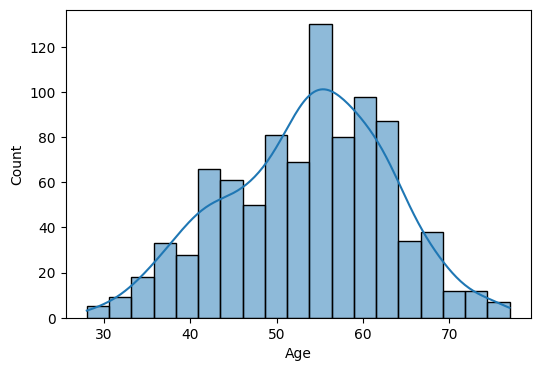

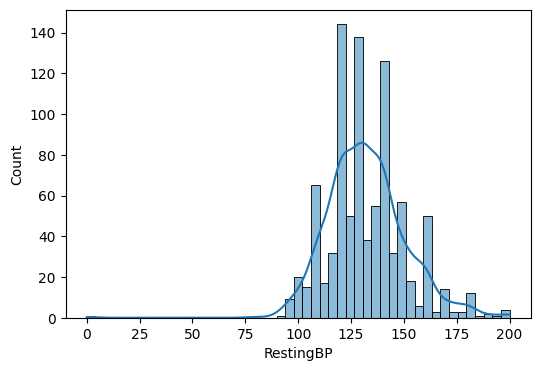

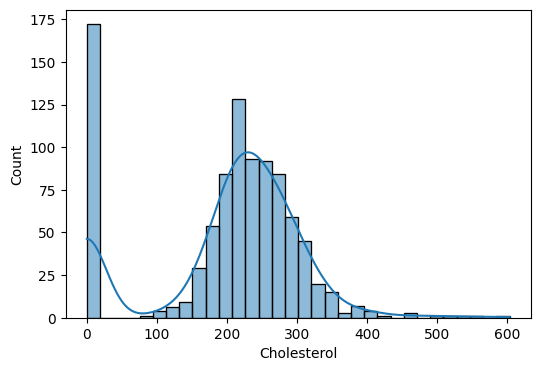

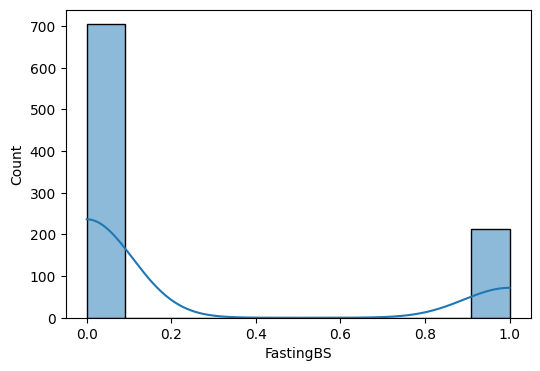

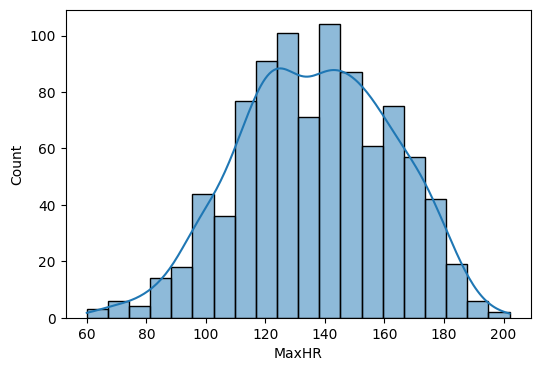

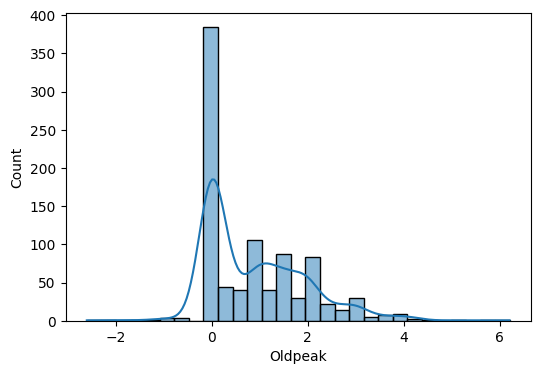

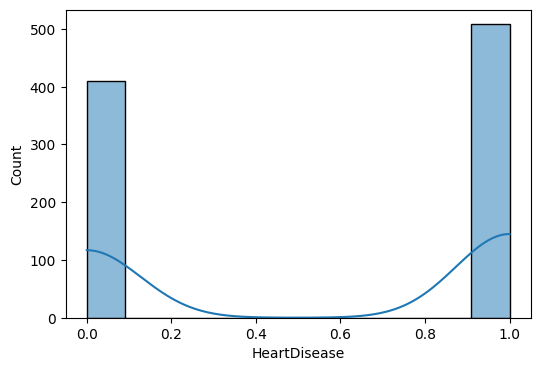

In [14]:
for col in columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)

In [15]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [16]:
def plotting(val,num):
    plt.subplot(2,2,num)
    sns.histplot(df[val], kde=True)

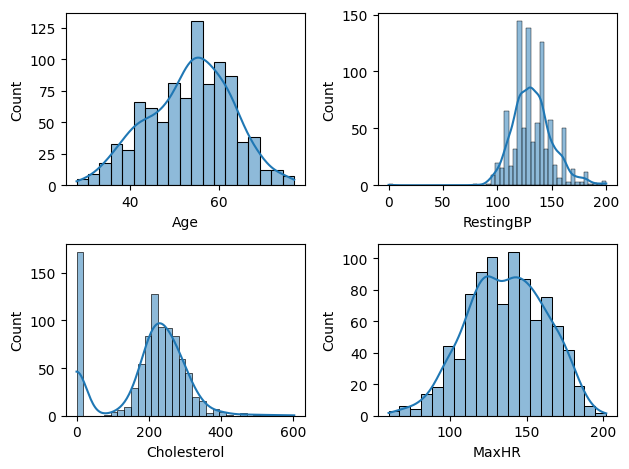

In [17]:
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

In [18]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [19]:
# ch_mean = df[df['Cholesterol'] != 0]['Cholesterol'].mean()  my way

In [20]:
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()

In [21]:
ch_mean

np.float64(244.6353887399464)

In [22]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [23]:
df['Cholesterol'].value_counts()

Cholesterol
244.64    172
254.00     11
220.00     10
223.00     10
204.00      9
         ... 
353.00      1
278.00      1
157.00      1
176.00      1
131.00      1
Name: count, Length: 222, dtype: int64

In [24]:
res_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()

In [25]:
res_mean

np.float64(132.54089422028352)

In [26]:
df['RestingBP'] = df['RestingBP'].replace(0, res_mean)
df['RestingBP'] = df['RestingBP'].round(2)

In [27]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


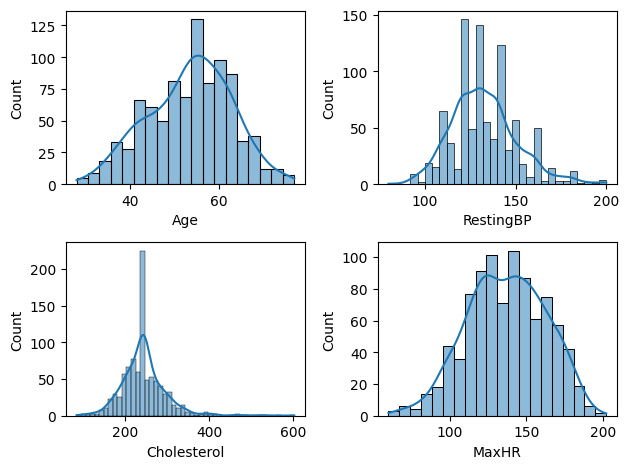

In [28]:
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

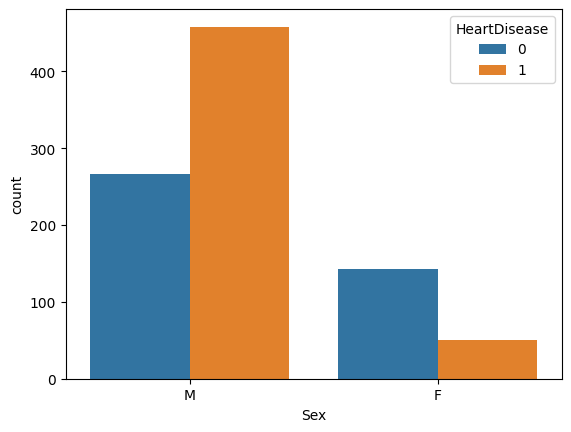

In [29]:
sns.countplot(x=df['Sex'], hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

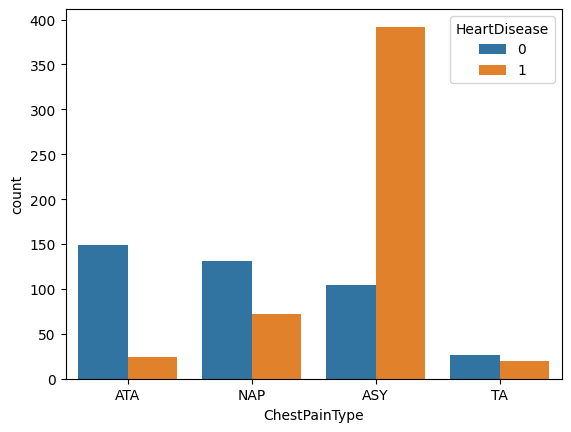

In [30]:
sns.countplot(x=df['ChestPainType'], hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

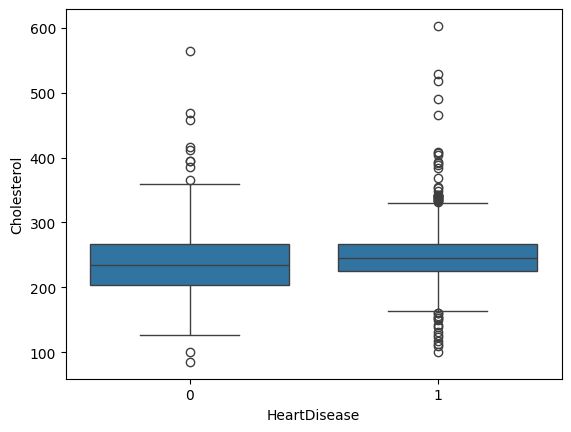

In [31]:
sns.boxplot(y=df['Cholesterol'], x=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

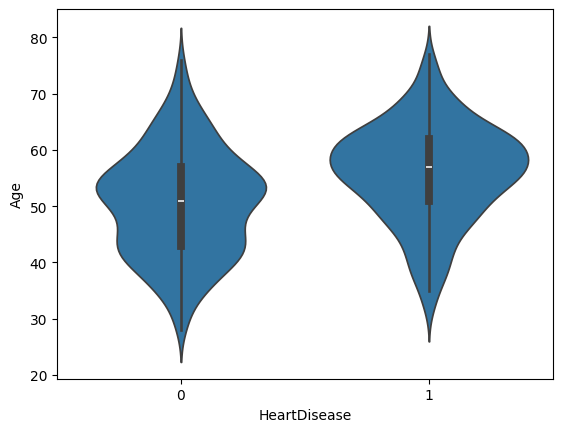

In [32]:
sns.violinplot(x='HeartDisease', y='Age', data=df)

<Axes: >

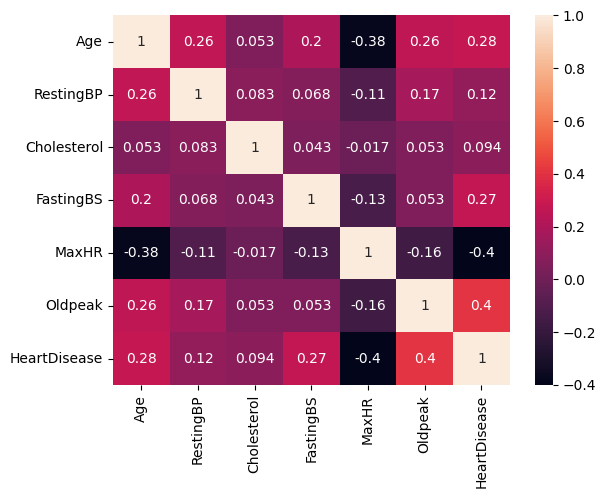

In [33]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Preprocessing and Cleaning

In [35]:
df_encode = pd.get_dummies(df)

In [36]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,False,True,False,...,False,True,False,True,False,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,False,True,True,...,False,False,False,True,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,False,True,True,...,False,False,False,True,False,False,True,False,True,False
916,57,130.0,236.0,0,174,0.0,1,True,False,False,...,False,False,True,False,False,True,False,False,True,False


In [37]:
df_encode = df_encode.astype(int)

In [38]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [39]:
from sklearn.preprocessing import StandardScaler
columns = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
df_encode[columns] = scaler.fit_transform(df[columns])

In [40]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832513,0,1.382928,-0.832432,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527192,-1.212938,0,0.754157,0.105664,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141317,0.719919,0,-1.525138,-0.832432,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303619,-0.574908,0,-1.132156,0.574711,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.971022,-0.931454,0,-0.581981,-0.832432,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


# Feature Engineering

In [87]:
df.sample(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
108,50,M,ASY,140.0,129.00,0,Normal,135,N,0.0,Up,0
228,41,M,ATA,120.0,295.00,0,Normal,170,N,0.0,Up,0
335,62,M,TA,120.0,244.64,1,LVH,134,N,-0.8,Flat,1
607,53,M,ASY,144.0,300.00,1,ST,128,Y,1.5,Flat,1
822,58,M,NAP,105.0,240.00,0,LVH,154,Y,0.6,Flat,0
414,54,M,ASY,130.0,244.64,1,Normal,110,Y,3.0,Flat,1
302,53,M,ASY,125.0,244.64,1,Normal,120,N,1.5,Up,1
352,56,M,ASY,120.0,244.64,0,ST,100,Y,-1.0,Down,1
869,59,M,NAP,150.0,212.00,1,Normal,157,N,1.6,Up,0
522,50,M,ASY,144.0,349.00,0,LVH,120,Y,1.0,Up,1


In [89]:
df['FastingBS'].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

In [111]:
df_copy = df.copy()

In [113]:
df_copy['RestingBP'] = pd.cut(df_copy['RestingBP'], bins=[0,90,120,130,140,180,float('inf')],labels=['Low BP','Normal','Elevated','High BP1','High BP2','Hypertensive Crisis'],right=False)

In [115]:
df_copy.sample(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
854,52,M,ATA,Elevated,325.00,0,Normal,172,N,0.2,Up,0
541,76,M,NAP,Normal,113.00,0,LVH,120,N,3.5,Down,1
565,61,M,ASY,High BP2,292.00,0,ST,115,Y,1.7,Flat,1
528,49,M,NAP,High BP1,142.00,0,Normal,127,Y,1.5,Flat,1
51,47,F,ASY,Elevated,205.00,0,Normal,98,Y,2.0,Flat,1
140,52,M,ASY,High BP2,331.00,0,Normal,94,Y,2.5,Flat,1
856,39,M,NAP,High BP2,321.00,0,LVH,182,N,0.0,Up,0
677,44,M,NAP,Elevated,226.00,0,Normal,169,N,0.0,Up,0
295,61,M,ASY,Normal,244.64,1,Normal,110,Y,1.5,Up,1
402,65,M,ASY,High BP2,244.64,1,ST,67,N,0.7,Flat,1


In [117]:
df_copy['RestingBP'].value_counts()

RestingBP
High BP2               307
High BP1               217
Elevated               214
Normal                 159
Hypertensive Crisis     20
Low BP                   1
Name: count, dtype: int64

In [119]:
df_copy = pd.get_dummies(df_copy, columns=['RestingBP'])

In [129]:
df_copy.head()

,Age,Sex,ChestPainType,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,RestingBP_Low BP,RestingBP_Normal,RestingBP_Elevated,RestingBP_High BP1,RestingBP_High BP2,RestingBP_Hypertensive Crisis
0,40,M,ATA,289.0,0,Normal,172,N,0.0,Up,0,False,False,False,False,True,False
1,49,F,NAP,180.0,0,Normal,156,N,1.0,Flat,1,False,False,False,False,True,False
2,37,M,ATA,283.0,0,ST,98,N,0.0,Up,0,False,False,False,True,False,False
3,48,F,ASY,214.0,0,Normal,108,Y,1.5,Flat,1,False,False,False,True,False,False
4,54,M,NAP,195.0,0,Normal,122,N,0.0,Up,0,False,False,False,False,True,False


In [131]:
df_copy['Sex'] = df_copy['Sex'].map({'M':0,'F':1})

In [135]:
df_copy.head()

,Age,Sex,ChestPainType,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,RestingBP_Low BP,RestingBP_Normal,RestingBP_Elevated,RestingBP_High BP1,RestingBP_High BP2,RestingBP_Hypertensive Crisis
0,40,0,ATA,289.0,0,Normal,172,N,0.0,Up,0,False,False,False,False,True,False
1,49,1,NAP,180.0,0,Normal,156,N,1.0,Flat,1,False,False,False,False,True,False
2,37,0,ATA,283.0,0,ST,98,N,0.0,Up,0,False,False,False,True,False,False
3,48,1,ASY,214.0,0,Normal,108,Y,1.5,Flat,1,False,False,False,True,False,False
4,54,0,NAP,195.0,0,Normal,122,N,0.0,Up,0,False,False,False,False,True,False


In [139]:
df_copy['ExerciseAngina'] = df_copy['ExerciseAngina'].map({'N':0, 'Y':1})

In [141]:
df_copy.head()

,Age,Sex,ChestPainType,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,RestingBP_Low BP,RestingBP_Normal,RestingBP_Elevated,RestingBP_High BP1,RestingBP_High BP2,RestingBP_Hypertensive Crisis
0,40,0,ATA,289.0,0,Normal,172,0,0.0,Up,0,False,False,False,False,True,False
1,49,1,NAP,180.0,0,Normal,156,0,1.0,Flat,1,False,False,False,False,True,False
2,37,0,ATA,283.0,0,ST,98,0,0.0,Up,0,False,False,False,True,False,False
3,48,1,ASY,214.0,0,Normal,108,1,1.5,Flat,1,False,False,False,True,False,False
4,54,0,NAP,195.0,0,Normal,122,0,0.0,Up,0,False,False,False,False,True,False


In [151]:
df_copy.rename(columns={'Sex':'is_female', 'ExerciseAngina':'is_exercise_angina'}, inplace=True)

In [155]:
df_copy = pd.get_dummies(df_copy, columns=['ChestPainType'])

In [157]:
df_copy.head()

,Age,is_female,Cholesterol,FastingBS,RestingECG,MaxHR,is_exercise_angina,Oldpeak,ST_Slope,HeartDisease,RestingBP_Low BP,RestingBP_Normal,RestingBP_Elevated,RestingBP_High BP1,RestingBP_High BP2,RestingBP_Hypertensive Crisis,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,0,289.0,0,Normal,172,0,0.0,Up,0,False,False,False,False,True,False,False,True,False,False
1,49,1,180.0,0,Normal,156,0,1.0,Flat,1,False,False,False,False,True,False,False,False,True,False
2,37,0,283.0,0,ST,98,0,0.0,Up,0,False,False,False,True,False,False,False,True,False,False
3,48,1,214.0,0,Normal,108,1,1.5,Flat,1,False,False,False,True,False,False,True,False,False,False
4,54,0,195.0,0,Normal,122,0,0.0,Up,0,False,False,False,False,True,False,False,False,True,False


In [165]:
df_copy = pd.get_dummies(df_copy, columns=['RestingECG','ST_Slope'])

In [167]:
df_copy.head()

,Age,is_female,Cholesterol,FastingBS,MaxHR,is_exercise_angina,Oldpeak,HeartDisease,RestingBP_Low BP,RestingBP_Normal,...,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,0,289.0,0,172,0,0.0,0,False,False,...,False,True,False,False,False,True,False,False,False,True
1,49,1,180.0,0,156,0,1.0,1,False,False,...,False,False,True,False,False,True,False,False,True,False
2,37,0,283.0,0,98,0,0.0,0,False,False,...,False,True,False,False,False,False,True,False,False,True
3,48,1,214.0,0,108,1,1.5,1,False,False,...,True,False,False,False,False,True,False,False,True,False
4,54,0,195.0,0,122,0,0.0,0,False,False,...,False,False,True,False,False,True,False,False,False,True


In [186]:
# df_copy['Cholesterol'] = pd.cut(
#     df_copy['Cholesterol'],
#     bins=[0, 200, 240, float('inf')],
#     labels=['Desirable', 'Borderline High', 'High'],
#     right=False
# )

In [182]:
df_copy.head()

,Age,is_female,Cholesterol,FastingBS,MaxHR,is_exercise_angina,Oldpeak,HeartDisease,RestingBP_Low BP,RestingBP_Normal,...,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,0,"[240.0, inf)",0,172,0,0.0,0,False,False,...,False,True,False,False,False,True,False,False,False,True
1,49,1,"[0.0, 200.0)",0,156,0,1.0,1,False,False,...,False,False,True,False,False,True,False,False,True,False
2,37,0,"[240.0, inf)",0,98,0,0.0,0,False,False,...,False,True,False,False,False,False,True,False,False,True
3,48,1,"[200.0, 240.0)",0,108,1,1.5,1,False,False,...,True,False,False,False,False,True,False,False,True,False
4,54,0,"[0.0, 200.0)",0,122,0,0.0,0,False,False,...,False,False,True,False,False,True,False,False,False,True
